# Step 1: Import Libraries and Load CIFAR-10 Dataset

In [1]:
!pip uninstall -y sympy
!pip install sympy==1.13.1

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 59.8 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires sympy>=1.13.3, but you have sympy 1.13.1 which is incompatible.


In [2]:
# =========================================================
# Step 1: Import Required Libraries and Load CIFAR-10 Dataset
# =========================================================

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ---------------------------------------------------------
# Define image preprocessing transformations
#
# 1. Convert images to PyTorch tensors
# 2. Normalize pixel values to improve training stability
#
# CIFAR-10 images are RGB images of size 32x32
# ---------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),

    # Normalize RGB channels
    # (mean = 0.5, std = 0.5 for each channel)
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# ---------------------------------------------------------
# Load CIFAR-10 Training Dataset
#
# train=True → loads training split (50,000 images)
# download=True → downloads dataset if not already present
# ---------------------------------------------------------

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# ---------------------------------------------------------
# Create Training DataLoader
#
# batch_size → number of images per batch
# shuffle=True → randomize data for better learning
# num_workers=2 → parallel loading for faster training
#
# NOTE:
# Using batch_size=64 instead of 4 for faster training
# and better GPU utilization in Kaggle notebooks
# ---------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

# ---------------------------------------------------------
# Load CIFAR-10 Test Dataset
#
# train=False → loads test split (10,000 images)
# ---------------------------------------------------------

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# ---------------------------------------------------------
# Create Test DataLoader
#
# shuffle=False → preserve order during evaluation
# ---------------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

# ---------------------------------------------------------
# CIFAR-10 Class Labels
# These are the 10 output classes for classification
# ---------------------------------------------------------

classes = (
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

# ---------------------------------------------------------
# Quick sanity check
# ---------------------------------------------------------

print("Training samples:", len(train_dataset))
print("Testing samples :", len(test_dataset))
print("Classes         :", classes)

100%|██████████| 170M/170M [00:02<00:00, 72.9MB/s] 


Training samples: 50000
Testing samples : 10000
Classes         : ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# Step 2: Visualize Sample Images from the CIFAR-10 Dataset

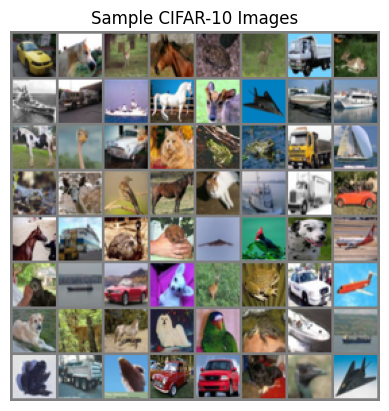

Labels:
car | horse | deer | horse | frog | deer | truck | deer | 

In [3]:
# =========================================================
# Step 2: Visualize Sample Images from CIFAR-10
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import torchvision

# ---------------------------------------------------------
# Function to display images
#
# Since we normalized the images earlier using:
# Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
#
# we need to reverse (unnormalize) that step before
# displaying them properly.
# ---------------------------------------------------------

def imshow(img):
    """
    Display an image using matplotlib.

    Parameters:
    img : torch.Tensor
        Image tensor in shape (C, H, W)
    """

    # Unnormalize the image
    img = img / 2 + 0.5

    # Convert tensor to NumPy array
    np_img = img.numpy()

    # Change shape from (C, H, W) → (H, W, C)
    plt.imshow(np.transpose(np_img, (1, 2, 0)))

    plt.title("Sample CIFAR-10 Images")
    plt.axis("off")
    plt.show()


# ---------------------------------------------------------
# Get a batch of random training images
# ---------------------------------------------------------

data_iterator = iter(train_loader)

# Fetch one batch
images, labels = next(data_iterator)

# ---------------------------------------------------------
# Display images in grid format
#
# torchvision.utils.make_grid() combines multiple images
# into one visual grid for easier viewing
# ---------------------------------------------------------

imshow(torchvision.utils.make_grid(images))

# ---------------------------------------------------------
# Print corresponding class labels
# ---------------------------------------------------------

print("Labels:")

for i in range(8):  # showing first 8 labels from batch
    print(f"{classes[labels[i]]}", end=" | ")

In [4]:
from collections import Counter

label_counts = Counter(train_dataset.targets)
print(label_counts)

Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


# Step 3: Defining the Custom Prunable Linear Layer

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [107]:
# =========================================================
# Step 3: Define the Custom Prunable Linear Layer
# (Improved Version with Better Gate Initialization)
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class PrunableLinear(nn.Module):
    """
    Custom Linear Layer with Learnable Gates

    Each weight has:
        1. Normal trainable weight
        2. Learnable gate score

    Gate values are computed using:

        gate = sigmoid(gate_score)

    Final effective weight:

        effective_weight = weight * gate

    This allows the network to learn which
    connections should remain active and
    which should be pruned automatically.
    """

    def __init__(self, in_features, out_features):
        """
        Parameters:
        in_features  : Number of input neurons
        out_features : Number of output neurons
        """

        super().__init__()

        # -------------------------------------------------
        # Standard trainable weights
        #
        # Shape:
        # (out_features, in_features)
        # -------------------------------------------------

        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01
        )

        # -------------------------------------------------
        # Standard trainable bias
        # -------------------------------------------------

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        # -------------------------------------------------
        # Learnable Gate Scores
        #
        # IMPORTANT IMPROVEMENT:
        #
        # Instead of random initialization:
        #
        #     torch.randn(...)
        #
        # we initialize with:
        #
        #     -2.0
        #
        # because:
        #
        # sigmoid(-2) ≈ 0.12
        #
        # This helps pruning happen more naturally.
        #
        # If initialized near 0:
        #
        # sigmoid(0) = 0.5
        #
        # then almost all gates start too active,
        # making pruning much harder.
        # -------------------------------------------------

        self.gate_scores = nn.Parameter(
            torch.ones(out_features, in_features) * -1.5
        )

    def forward(self, x):
        """
        Forward Pass

        Steps:
        1. Convert gate scores → gate values using sigmoid
        2. Multiply weights by gates
        3. Apply linear transformation

        Final:

            y = x(W * gate) + bias
        """

        # Convert gate scores to values between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # Apply pruning effect
        pruned_weights = self.weight * gates

        # Standard linear transformation
        return F.linear(x, pruned_weights, self.bias)

# Step 4 : Building the Self-Pruning Neural Network


In [108]:
# =========================================================
# Step 4: Build the Self-Pruning Neural Network
# =========================================================


class PrunableNet(nn.Module):
    """
    Feed Forward Neural Network using PrunableLinear layers

    Architecture:

    Input → Flatten
          → PrunableLinear
          → BatchNorm
          → ReLU
          → PrunableLinear
          → BatchNorm
          → ReLU
          → PrunableLinear
          → Output

    Final output:
        10 classes for CIFAR-10 classification
    """

    def __init__(self):
        super().__init__()

        # -------------------------------------------------
        # First hidden layer
        #
        # CIFAR-10 image:
        # 32 x 32 x 3 = 3072 input features
        # -------------------------------------------------

        self.fc1 = PrunableLinear(
            in_features=32 * 32 * 3,
            out_features=512
        )

        self.bn1 = nn.BatchNorm1d(512)

        # -------------------------------------------------
        # Second hidden layer
        # -------------------------------------------------

        self.fc2 = PrunableLinear(
            in_features=512,
            out_features=256
        )

        self.bn2 = nn.BatchNorm1d(256)

        # -------------------------------------------------
        # Output layer
        #
        # 10 output classes for CIFAR-10
        # -------------------------------------------------

        self.fc3 = PrunableLinear(
            in_features=256,
            out_features=10
        )

    def forward(self, x):
        """
        Forward pass of the network
        """

        # ---------------------------------------------
        # Flatten image:
        # (batch_size, 3, 32, 32)
        #
        # becomes
        #
        # (batch_size, 3072)
        # ---------------------------------------------

        x = x.view(x.size(0), -1)

        # ---------------------------------------------
        # Layer 1
        # ---------------------------------------------

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # ---------------------------------------------
        # Layer 2
        # ---------------------------------------------

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)

        # ---------------------------------------------
        # Output Layer
        # ---------------------------------------------

        x = self.fc3(x)

        return x

    def get_all_gates(self):
        """
        Collect all gate values from every PrunableLinear layer

        This is needed for:
        - sparsity loss calculation
        - sparsity percentage evaluation
        - gate distribution plotting
        """

        gates = []

        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates.append(
                    torch.sigmoid(module.gate_scores)
                )

        return gates

# Step 5: Visualize the Network Architecture

In [109]:
# =========================================================
# Step 5: Visualize the Network Architecture
# =========================================================

# Create model instance
model = PrunableNet()

# Print full model architecture
print(model)

PrunableNet(
  (fc1): PrunableLinear()
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): PrunableLinear()
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): PrunableLinear()
)


In [110]:
# Count total trainable parameters

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 3,415,306


# Step 6: Define the Sparsity Loss (L1 Regularization on Gates)

In [111]:
# =========================================================
# Step 5: Define Sparsity Loss
# =========================================================

import torch.nn as nn

# ---------------------------------------------------------
# Standard classification loss
#
# Since CIFAR-10 is a multi-class classification problem,
# CrossEntropyLoss is the correct choice
# ---------------------------------------------------------

criterion = nn.CrossEntropyLoss()


def compute_sparsity_loss(model):
    """
    Compute L1 Sparsity Loss using all gate values

    Formula:

        Sparsity Loss = sum(all gate values)

    Since:

        gate = sigmoid(gate_scores)

    and sigmoid outputs values between 0 and 1,

    minimizing this loss pushes gates toward zero,
    which effectively prunes unnecessary weights.
    """

    sparsity_loss = 0.0

    # Loop through all PrunableLinear layers
    for gates in model.get_all_gates():

        # Since gates are always positive,
        # L1 norm becomes simple summation
        sparsity_loss += gates.sum()

    return sparsity_loss

In [112]:
model = PrunableNet()

loss = compute_sparsity_loss(model)

print("Initial Sparsity Loss:", loss.item())

Initial Sparsity Loss: 311308.40625


In [ ]:
# =========================================================
# Step 6: Setup Device and Optimizer
# =========================================================

import torch.optim as optim

# ---------------------------------------------------------
# Select device
#
# If GPU is available in Kaggle:
#     use CUDA
#
# Otherwise:
#     use CPU
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

# ---------------------------------------------------------
# Create model instance
# and move it to selected device
# ---------------------------------------------------------

model = PrunableNet().to(device)

# ---------------------------------------------------------
# Optimizer
#
# Adam is used for:
# - stable learning
# - better convergence
# - smoother gate optimization
#
# lr = 1e-3 is the best practical choice here
# ---------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
    
)

# ---------------------------------------------------------
# Initial lambda value
#
# Controls sparsity strength
#
# Start with:
# lambda = 1e-3
#
# Later we will compare multiple values
# ---------------------------------------------------------

lambda_val = 1e-3

print(f"Initial Lambda Value: {lambda_val}")

# Step 7: Train the Self-Pruning Neural Network

In [121]:
# =========================================================
# Step 7: Training Loop
# =========================================================

# Number of complete passes through the training dataset
epochs = 6


# Set model to training mode
model.train()

for epoch in range(epochs):

    # Track total loss for this epoch
    total_loss_epoch = 0.0

    # -----------------------------------------------------
    # Loop through training batches
    # -----------------------------------------------------

    for inputs, targets in train_loader:

        # Move data to GPU/CPU
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # ---------------------------------------------
        # Forward pass
        # ---------------------------------------------

        outputs = model(inputs)

        # ---------------------------------------------
        # Classification Loss
        # ---------------------------------------------

        cls_loss = criterion(outputs, targets)

        # ---------------------------------------------
        # Sparsity Loss
        # ---------------------------------------------

        sparsity_loss = compute_sparsity_loss(model)

        # ---------------------------------------------
        # Total Loss
        # ---------------------------------------------

        total_loss = (
            cls_loss
            + lambda_val * sparsity_loss
        )

        # ---------------------------------------------
        # Backpropagation
        # ---------------------------------------------

        total_loss.backward()
        optimizer.step()

        # Add batch loss to epoch total
        total_loss_epoch += total_loss.item()

    # -----------------------------------------------------
    # Print progress after each epoch
    # -----------------------------------------------------

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Total Loss: {total_loss_epoch:.2f}"
    )

Epoch [1/6] | Total Loss: 73340.69
Epoch [2/6] | Total Loss: 47713.87
Epoch [3/6] | Total Loss: 32556.27
Epoch [4/6] | Total Loss: 23062.31
Epoch [5/6] | Total Loss: 16893.43
Epoch [6/6] | Total Loss: 12780.27


# Step 8: Evaluate Model Accuracy and Sparsity

In [119]:
# =========================================================
# Step 8: Evaluate Accuracy and Sparsity
# =========================================================


def compute_sparsity(model, threshold=1e-2):
    """
    Compute percentage of pruned connections

    A connection is considered pruned if:

        gate < threshold

    Default threshold:
        0.01
    """

    total_gates = 0
    pruned_gates = 0

    # Loop through all PrunableLinear layers
    for module in model.modules():

        if isinstance(module, PrunableLinear):

            # Convert gate scores to actual gate values
            gates = torch.sigmoid(module.gate_scores)

            # Total number of gates
            total_gates += gates.numel()

            # Count gates smaller than threshold
            pruned_gates += (gates < threshold).sum().item()

    sparsity_percentage = (
        pruned_gates / total_gates
    ) * 100

    return sparsity_percentage


def evaluate(model, test_loader, device):
    """
    Compute classification accuracy on test dataset
    """

    # Set model to evaluation mode
    model.eval()

    correct = 0
    total = 0

    # Disable gradient computation
    with torch.no_grad():

        for inputs, targets in test_loader:

            # Move data to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            outputs = model(inputs)

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            total += targets.size(0)
            correct += (
                predicted == targets
            ).sum().item()

    accuracy = (correct / total) * 100

    return accuracy


# ---------------------------------------------------------
# Run evaluation
# ---------------------------------------------------------

accuracy = evaluate(model, test_loader, device)
sparsity = compute_sparsity(model)

print(f"Test Accuracy : {accuracy:.2f}%")
print(f"Sparsity      : {sparsity:.2f}%")

Test Accuracy : 55.44%
Sparsity      : 99.10%


# Step 9: Compare Multiple Lambda Values

In [120]:
# =========================================================
# Step 9: Compare Multiple Lambda Values
# (Final Improved Version)
# =========================================================

import torch.optim as optim

# ---------------------------------------------------------
# Lambda values to compare
#
# 1e-4 → weak pruning
# 1e-3 → moderate pruning
# 1e-2 → strong pruning
# ---------------------------------------------------------

lambda_values = [1e-4, 1e-3, 1e-2]

# ---------------------------------------------------------
# Use more epochs because pruning needs time
# to fully develop
# ---------------------------------------------------------

epochs = 5

# Store final results
results = []

for lambda_val in lambda_values:

    print(f"\n===== Training with lambda = {lambda_val} =====")

    # -----------------------------------------------------
    # Create a fresh model for each lambda
    #
    # VERY IMPORTANT:
    # Never reuse old model
    # -----------------------------------------------------

    model = PrunableNet().to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    # Set training mode
    model.train()

    # -----------------------------------------------------
    # Training Loop
    # -----------------------------------------------------

    for epoch in range(epochs):

        total_loss_epoch = 0.0

        for inputs, targets in train_loader:

            # Move batch to GPU / CPU
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Clear old gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Classification loss
            cls_loss = criterion(outputs, targets)

            # Sparsity loss
            sparsity_loss = compute_sparsity_loss(model)

            # Total loss
            total_loss = (
                cls_loss
                + lambda_val * sparsity_loss
            )

            # Backpropagation
            total_loss.backward()
            optimizer.step()

            total_loss_epoch += total_loss.item()

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Loss: {total_loss_epoch:.2f}"
        )

    # -----------------------------------------------------
    # Final Evaluation
    # -----------------------------------------------------

    accuracy = evaluate(model, test_loader, device)
    sparsity = compute_sparsity(model)

    print(
        f"Lambda: {lambda_val} | "
        f"Accuracy: {accuracy:.2f}% | "
        f"Sparsity: {sparsity:.2f}%"
    )

    # Save results
    results.append(
        (lambda_val, accuracy, sparsity)
    )


===== Training with lambda = 0.0001 =====
Epoch [1/5] | Loss: 19581.37
Epoch [2/5] | Loss: 11924.78
Epoch [3/5] | Loss: 8189.28
Epoch [4/5] | Loss: 6125.07
Epoch [5/5] | Loss: 4880.47
Lambda: 0.0001 | Accuracy: 55.75% | Sparsity: 0.00%

===== Training with lambda = 0.001 =====
Epoch [1/5] | Loss: 183063.14


KeyboardInterrupt: 

In [ ]:
for gates in model.get_all_gates():
    print(
        "Min:", gates.min().item(),
        "Mean:", gates.mean().item()
    )

In [ ]:
def get_all_gates(self):
    gates = []
    for module in self.modules():
        if isinstance(module, PrunableLinear):
            gates.append(torch.sigmoid(module.gate_scores))
    return gates

In [ ]:
criterion = nn.CrossEntropyLoss()
def compute_sparsity_loss(model):
    sparsity_loss = 0.0

    for gates in model.get_all_gates():
        sparsity_loss += gates.sum()   # L1 (since gates ≥ 0)

    return sparsity_loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = PrunableLinear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.fc3(x)

        return x

    def get_all_gates(self):
        gates = []
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates.append(torch.sigmoid(module.gate_scores))
        return gates

In [ ]:
def compute_sparsity_loss(model):
    sparsity_loss = 0.0
    for gates in model.get_all_gates():
        sparsity_loss += gates.sum()
    return sparsity_loss

In [ ]:
model = PrunableNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

lambda_val = 1e-2

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
model.train()

epochs = 5

for epoch in range(epochs):

    total_loss_epoch = 0

    for inputs, targets in train_loader:

        optimizer.zero_grad()

        outputs = model(inputs)

        cls_loss = criterion(outputs, targets)
        sparsity_loss = compute_sparsity_loss(model)

        total_loss = cls_loss + lambda_val * sparsity_loss

        total_loss.backward()
        optimizer.step()

        total_loss_epoch += total_loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss_epoch:.4f}")

In [ ]:
def compute_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    sparsity = (pruned / total) * 100
    return sparsity

In [ ]:
sparsity = compute_sparsity(model)
print(f"Sparsity: {sparsity:.2f}%")

In [ ]:
def evaluate(model, test_loader, device="cpu"):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
acc = evaluate(model, test_loader)
sparsity = compute_sparsity(model)

print(f"Accuracy: {acc:.2f}%")
print(f"Sparsity: {sparsity:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        g = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
        all_gates.extend(g.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
for gates in model.get_all_gates():
    print(gates.min().item(), gates.mean().item())

In [ ]:
import torch
import torch.nn as nn

lambda_values = [1e-4, 1e-3, 1e-2]
epochs = 10   # keep small for now

results = []

for lambda_val in lambda_values:

    print(f"\n===== Training with lambda = {lambda_val} =====")

    # Fresh model each time
    model = PrunableNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # -------- Training --------
    for epoch in range(epochs):
        model.train()

        total_loss_epoch = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            cls_loss = criterion(outputs, targets)
            sparsity_loss = compute_sparsity_loss(model)

            total_loss = cls_loss + lambda_val * sparsity_loss

            total_loss.backward()
            optimizer.step()

            total_loss_epoch += total_loss.item()

        print(f"Epoch {epoch+1}: Loss = {total_loss_epoch:.2f}")

    # -------- Evaluation --------
    acc = evaluate(model, test_loader, device)
    sparsity = compute_sparsity(model)

    print(f"Lambda: {lambda_val} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

    results.append((lambda_val, acc, sparsity))

In [ ]:
import matplotlib.pyplot as plt

all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        g = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
        all_gates.extend(g.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate value")
plt.ylabel("Frequency")
plt.show()